# 2. 로컬 평면좌표(ENU 좌표계, East-North-Up) 세팅

특정 기준점(lat0,lng0)을 잡고, 위경도 차이를 **직교좌표(m)** 로 바꾸기

## 1) import & 그래프/건물 로드

In [1]:
from pathlib import Path
import math
import pickle
import pandas as pd
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt

In [2]:
ARTIFACTS_DIR = Path("../artifacts")

with open(ARTIFACTS_DIR / "graph_base.pkl", "rb") as f:
    G = pickle.load(f)

buildings = pd.read_parquet(ARTIFACTS_DIR / "buildings.parquet")
print(G.number_of_nodes(), G.number_of_edges(), len(buildings))

330 440 116


## 2) 기준점 (위도, 경도) 잡기

In [3]:
lats = np.array([G.nodes[n]["lat"] for n in G.nodes])
lngs = np.array([G.nodes[n]["lng"] for n in G.nodes])
lat0 = float(lats.mean())
lng0 = float(lngs.mean())
lat0, lng0

(35.88955176060607, 128.6115757)

## 3) 위경도 ⇄ 평면(x,y) 변환 함수

* equirectangular projection(등거리 원통 투영) 근사:
- **x ≈ R * (lon-lon0) * cos(lat0)** <- 경도(lon)는 위도(lat0)의 cos 값으로 보정해서 x축에 비례
- **y ≈ R * (lat-lat0)** <- 위도(lat)는 그대로 y축에 비례

반경 R= 6371000m, 캠퍼스 크기(수 km 미만)에서는 오류 수십 cm~수 m 이내.

In [4]:
R = 6371000.0  # meters

def ll_to_xy(lat, lng, lat0=lat0, lng0=lng0):
    """WGS84 위경도 -> 로컬 평면(m)."""
    dlat = math.radians(lat - lat0)
    dlng = math.radians(lng - lng0)
    x = R * dlng * math.cos(math.radians(lat0))
    y = R * dlat
    return x, y

def xy_to_ll(x, y, lat0=lat0, lng0=lng0):
    """로컬 평면(m) -> WGS84 위경도."""
    dlat = y / R
    dlng = x / (R * math.cos(math.radians(lat0)))
    lat = math.degrees(dlat) + lat0
    lng = math.degrees(dlng) + lng0
    return lat, lng

## 4) 노드에 x,y 추가

In [5]:
for n in G.nodes:
    lat = G.nodes[n]["lat"]; lng = G.nodes[n]["lng"]
    x, y = ll_to_xy(lat, lng)
    G.nodes[n]["x"] = x
    G.nodes[n]["y"] = y

In [6]:
# 간선에 평면 길이도 추가(검증용)
for u, v, d in G.edges(data=True):
    x1, y1 = G.nodes[u]["x"], G.nodes[u]["y"]
    x2, y2 = G.nodes[v]["x"], G.nodes[v]["y"]
    d["length_xy_m"] = math.hypot(x2-x1, y2-y1)

In [7]:
print("예시 노드:", list(G.nodes(data=True))[:1])

예시 노드: [(1, {'lat': 35.887091, 'lng': 128.6067, 'x': -439.2245539913579, 'y': -273.6240950817526})]


# 5) 왕복 변환 정확도 확인

In [8]:
# 임의 20개 노드에 대해 ll -> xy -> ll 왕복 오차 확인
nodes_sample = list(G.nodes)[:20]
errs = []
for n in nodes_sample:
    lt, lg = G.nodes[n]["lat"], G.nodes[n]["lng"]
    x, y = ll_to_xy(lt, lg)
    lt2, lg2 = xy_to_ll(x, y)
    dlat_m = (lt2 - lt) * (R) * math.pi/180
    dlng_m = (lg2 - lg) * (R) * math.pi/180 * math.cos(math.radians(lat0))
    errs.append(math.hypot(dlat_m, dlng_m))

print(f"왕복 평균오차: {np.mean(errs):.3f} m, 최대오차: {np.max(errs):.3f} m")


왕복 평균오차: 0.000 m, 최대오차: 0.000 m


## 6) 평면상 간단 플롯(형상 체크)

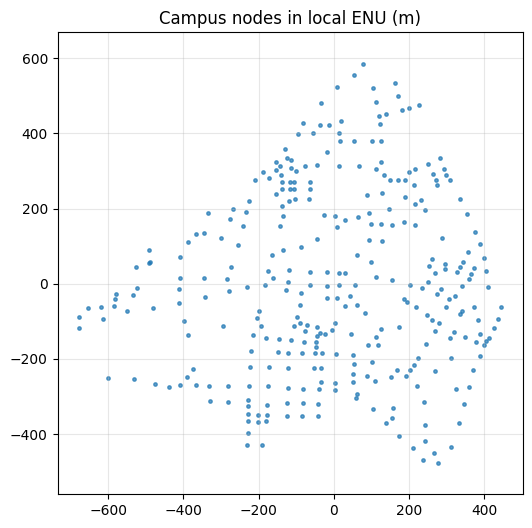

In [9]:
plt.figure(figsize=(6,6))
xs = [G.nodes[n]["x"] for n in G.nodes]
ys = [G.nodes[n]["y"] for n in G.nodes]
plt.scatter(xs, ys, s=6, alpha=0.7)
plt.title("Campus nodes in local ENU (m)")
plt.axis("equal"); plt.grid(True, alpha=0.3)
plt.show()

## 7) 빌딩 좌표도 x,y 추가하기

In [10]:
print("건물 수:", len(buildings))

건물 수: 116


In [11]:
bx, by = [], []
for lat, lng in zip(buildings["lat"], buildings["lng"]):
    x, y = ll_to_xy(lat, lng)
    bx.append(x); by.append(y)

buildings["x"] = bx; buildings["y"] = by

buildings.head()

,building_name,dong_num,area,height,lat,lng,radius,Unnamed: 7,x,y
0,P/P공대구조실습실,403.구조실습실,1331.75,20.30,35.887395,128.607729,20.589055,NaN,-346.536705,-239.771026
1,경북대학교,24.자연과학대학,1338.60,21.60,35.890262,128.606590,20.641938,NaN,-449.114334,78.996093
2,경북대학교,131.동물사육장,80.41,4.22,35.889322,128.606741,5.059180,NaN,-435.565378,-25.560087
3,경북대학교,23.사회과학대학,2586.39,19.65,35.888541,128.615588,28.692743,NaN,361.468994,-112.413465
4,경북대학교,55.사과포장개발실,342.30,7.15,35.890790,128.609189,10.438270,NaN,-214.964570,137.675888


## 8) 저장

In [12]:
with open(ARTIFACTS_DIR / "graph_xy.pkl", "wb") as f:
    pickle.dump(G, f)

buildings.to_parquet(ARTIFACTS_DIR / "buildings_xy.parquet", index=False)
print("저장 완료:", ARTIFACTS_DIR)

저장 완료: ..\artifacts
